# Experiment Results

Visualizes architecture synthesis experiment metrics from `.stats` and `.statscompare` files.
Data is auto-discovered under `code/data/final` (or `data/final`).

Run from the `code/` directory: `uv run jupyter notebook notebooks/experiment_results.ipynb`

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "notebooks").is_dir():
    sys.path.insert(0, str(NOTEBOOK_DIR / "notebooks"))
else:
    for parent in NOTEBOOK_DIR.parents:
        candidate = parent / "code" / "notebooks"
        if candidate.is_dir():
            sys.path.insert(0, str(candidate))
            break

from _experiment_viz import (
    MetricSection,
    all_required_metrics,
    apply_labels,
    discover_data_dir,
    load_all_results,
    render_section,
    setup_style,
)
from IPython.display import display

SHORT_LABELS: dict[str, str] = {
    "add": "ADD",
    "pps": "PPS",
    "pp": "PP",
    "arlo": "ARLO",
    "EventTicketSystem": "ETS",
    "HotelPricingSystem": "HPS",
    "pitstop": "Pitstop",
}

METRIC_SECTIONS: list[MetricSection] = [
    {
        "title": "Average Dependency Degree",
        "metrics": ["dep_avg"],
        "ylabel": "Avg Dep Degree",
    },
    {
        "title": "Average Change Impact",
        "metrics": ["average_change_impact"],
        "ylabel": "Avg Change Impact",
    },
    {
        "title": "Node Recall, Precision, F1",
        "metrics": ["node_recall", "node_precision", "node_f1"],
        "ylabel": "Score",
    },
    {
        "title": "Edge Recall, Precision, F1",
        "metrics": ["edge_recall", "edge_precision", "edge_f1"],
        "ylabel": "Score",
    },
]

In [2]:
data_dir = discover_data_dir()
required = all_required_metrics(METRIC_SECTIONS)
df = load_all_results(data_dir, required)
df = apply_labels(df, SHORT_LABELS)
display(df.head())

,method,app,dep_avg,average_change_impact,node_precision,node_recall,node_f1,edge_precision,edge_recall,edge_f1,base_node_count,generated_node_count,common_node_count,base_edge_count,generated_edge_count,common_edge_count,method_label,app_label
0,add,EventTicketSystem,1.571429,0.280612,0.857143,0.923077,0.888889,0.795455,0.603448,0.686275,26,28,24,58,44,35,ADD,ETS
1,add,HotelPricingSystem,1.578947,0.299169,0.842105,0.800000,0.820513,0.533333,0.615385,0.571429,20,19,16,26,30,16,ADD,HPS
2,add,pitstop,1.550000,0.255000,0.950000,0.950000,0.950000,0.612903,0.904762,0.730769,20,20,19,21,31,19,ADD,Pitstop
3,pps,EventTicketSystem,1.297297,0.092038,0.702703,1.000000,0.825397,0.666667,0.551724,0.603774,26,37,26,58,48,32,PPS,ETS
4,pps,HotelPricingSystem,1.050000,0.140000,0.750000,0.750000,0.750000,0.476190,0.384615,0.425532,20,20,15,26,21,10,PPS,HPS


## Average Dependency Degree

### By Method

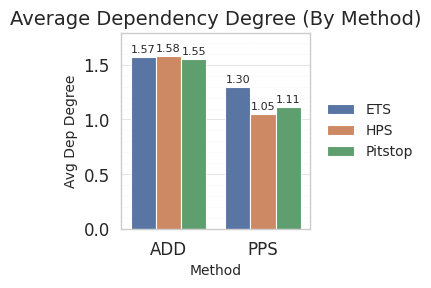

**Average Dependency Degree — By Method (Aggregated)**

App,ETS,HPS,Pitstop
Method,,,
ADD,1.571,1.579,1.550
PPS,1.297,1.050,1.111


\begin{tabular}{lrrr}
\toprule
App & ETS & HPS & Pitstop \\
Method &  &  &  \\
\midrule
ADD & 1.571 & 1.579 & 1.550 \\
PPS & 1.297 & 1.050 & 1.111 \\
\bottomrule
\end{tabular}



### By App

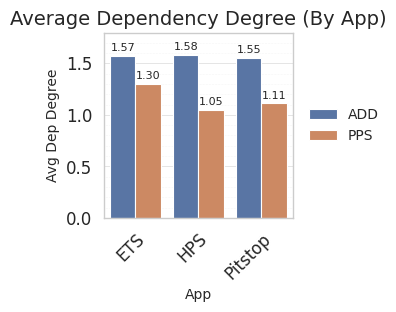

**Average Dependency Degree — By App (Aggregated)**

Method,ADD,PPS
App,,
ETS,1.571,1.297
HPS,1.579,1.050
Pitstop,1.550,1.111


\begin{tabular}{lrr}
\toprule
Method & ADD & PPS \\
App &  &  \\
\midrule
ETS & 1.571 & 1.297 \\
HPS & 1.579 & 1.050 \\
Pitstop & 1.550 & 1.111 \\
\bottomrule
\end{tabular}



**Average Dependency Degree — Unaggregated**

,Method,App,Dep Avg
0,ADD,ETS,1.571
1,ADD,HPS,1.579
2,ADD,Pitstop,1.550
3,PPS,ETS,1.297
4,PPS,HPS,1.050
5,PPS,Pitstop,1.111


\begin{tabular}{lllr}
\toprule
 & Method & App & Dep Avg \\
\midrule
0 & ADD & ETS & 1.571 \\
1 & ADD & HPS & 1.579 \\
2 & ADD & Pitstop & 1.550 \\
3 & PPS & ETS & 1.297 \\
4 & PPS & HPS & 1.050 \\
5 & PPS & Pitstop & 1.111 \\
\bottomrule
\end{tabular}



## Average Change Impact

### By Method

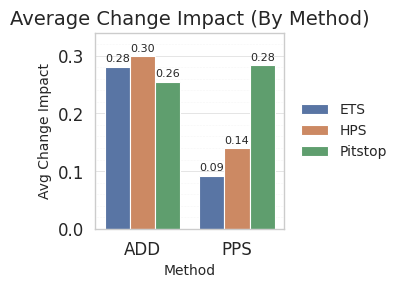

**Average Change Impact — By Method (Aggregated)**

App,ETS,HPS,Pitstop
Method,,,
ADD,0.281,0.299,0.255
PPS,0.092,0.140,0.284


\begin{tabular}{lrrr}
\toprule
App & ETS & HPS & Pitstop \\
Method &  &  &  \\
\midrule
ADD & 0.281 & 0.299 & 0.255 \\
PPS & 0.092 & 0.140 & 0.284 \\
\bottomrule
\end{tabular}



### By App

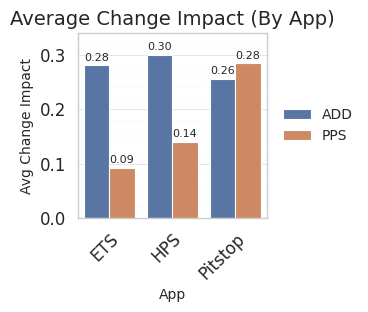

**Average Change Impact — By App (Aggregated)**

Method,ADD,PPS
App,,
ETS,0.281,0.092
HPS,0.299,0.140
Pitstop,0.255,0.284


\begin{tabular}{lrr}
\toprule
Method & ADD & PPS \\
App &  &  \\
\midrule
ETS & 0.281 & 0.092 \\
HPS & 0.299 & 0.140 \\
Pitstop & 0.255 & 0.284 \\
\bottomrule
\end{tabular}



**Average Change Impact — Unaggregated**

,Method,App,Average Change Impact
0,ADD,ETS,0.281
1,ADD,HPS,0.299
2,ADD,Pitstop,0.255
3,PPS,ETS,0.092
4,PPS,HPS,0.140
5,PPS,Pitstop,0.284


\begin{tabular}{lllr}
\toprule
 & Method & App & Average Change Impact \\
\midrule
0 & ADD & ETS & 0.281 \\
1 & ADD & HPS & 0.299 \\
2 & ADD & Pitstop & 0.255 \\
3 & PPS & ETS & 0.092 \\
4 & PPS & HPS & 0.140 \\
5 & PPS & Pitstop & 0.284 \\
\bottomrule
\end{tabular}



## Node Recall, Precision, F1

### By Method

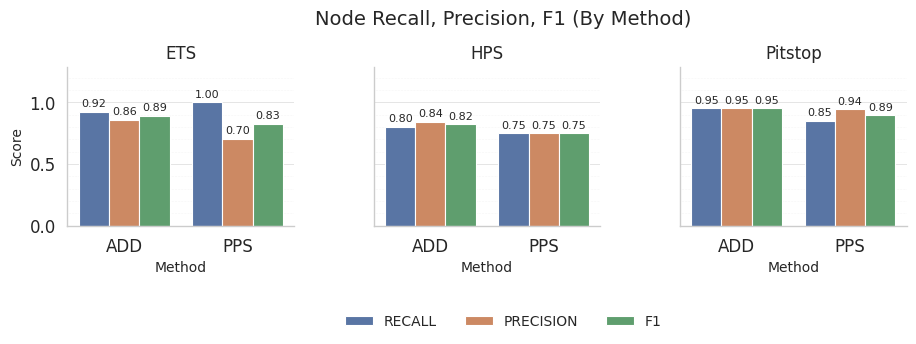

**Node Recall, Precision, F1 — By Method (Aggregated)**

RECALL               PRECISION                    F1               
app_label    ETS   HPS Pitstop       ETS    HPS Pitstop    ETS    HPS Pitstop
Method                                                                       
ADD        0.923  0.80    0.95     0.857  0.842   0.950  0.889  0.821   0.950
PPS        1.000  0.75    0.85     0.703  0.750   0.944  0.825  0.750   0.895

\begin{tabular}{lrrrrrrrrr}
\toprule
 & \multicolumn{3}{r}{RECALL} & \multicolumn{3}{r}{PRECISION} & \multicolumn{3}{r}{F1} \\
app_label & ETS & HPS & Pitstop & ETS & HPS & Pitstop & ETS & HPS & Pitstop \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
ADD & 0.923 & 0.800 & 0.950 & 0.857 & 0.842 & 0.950 & 0.889 & 0.821 & 0.950 \\
PPS & 1.000 & 0.750 & 0.850 & 0.703 & 0.750 & 0.944 & 0.825 & 0.750 & 0.895 \\
\bottomrule
\end{tabular}



### By App

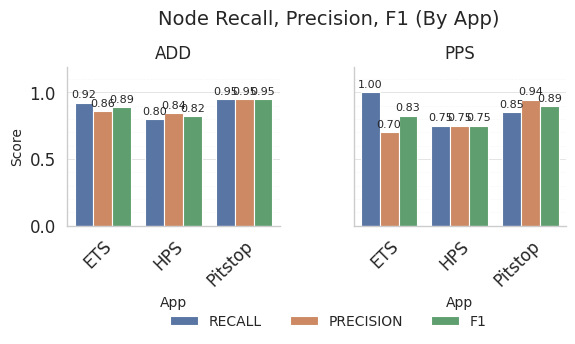

**Node Recall, Precision, F1 — By App (Aggregated)**

RECALL       PRECISION            F1       
method_label    ADD   PPS       ADD    PPS    ADD    PPS
App                                                     
ETS           0.923  1.00     0.857  0.703  0.889  0.825
HPS           0.800  0.75     0.842  0.750  0.821  0.750
Pitstop       0.950  0.85     0.950  0.944  0.950  0.895

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{RECALL} & \multicolumn{2}{r}{PRECISION} & \multicolumn{2}{r}{F1} \\
method_label & ADD & PPS & ADD & PPS & ADD & PPS \\
App &  &  &  &  &  &  \\
\midrule
ETS & 0.923 & 1.000 & 0.857 & 0.703 & 0.889 & 0.825 \\
HPS & 0.800 & 0.750 & 0.842 & 0.750 & 0.821 & 0.750 \\
Pitstop & 0.950 & 0.850 & 0.950 & 0.944 & 0.950 & 0.895 \\
\bottomrule
\end{tabular}



**Node Recall, Precision, F1 — Unaggregated**

,Method,App,RECALL,PRECISION,F1
0,ADD,ETS,0.923,0.857,0.889
1,ADD,HPS,0.800,0.842,0.821
2,ADD,Pitstop,0.950,0.950,0.950
3,PPS,ETS,1.000,0.703,0.825
4,PPS,HPS,0.750,0.750,0.750
5,PPS,Pitstop,0.850,0.944,0.895


\begin{tabular}{lllrrr}
\toprule
 & Method & App & RECALL & PRECISION & F1 \\
\midrule
0 & ADD & ETS & 0.923 & 0.857 & 0.889 \\
1 & ADD & HPS & 0.800 & 0.842 & 0.821 \\
2 & ADD & Pitstop & 0.950 & 0.950 & 0.950 \\
3 & PPS & ETS & 1.000 & 0.703 & 0.825 \\
4 & PPS & HPS & 0.750 & 0.750 & 0.750 \\
5 & PPS & Pitstop & 0.850 & 0.944 & 0.895 \\
\bottomrule
\end{tabular}



## Edge Recall, Precision, F1

### By Method

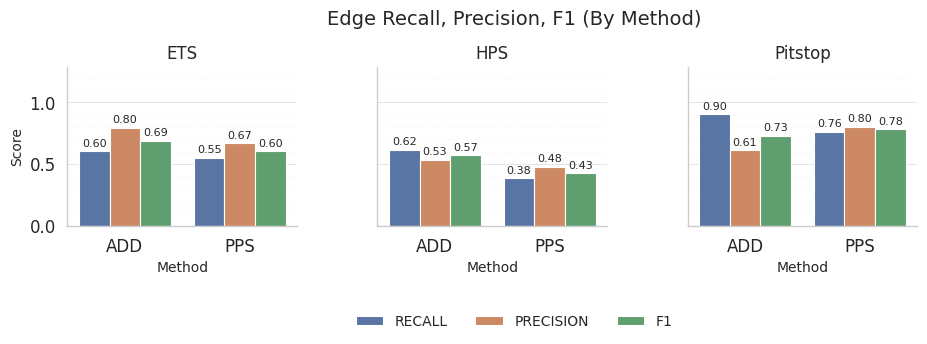

**Edge Recall, Precision, F1 — By Method (Aggregated)**

RECALL                PRECISION                    F1               
app_label    ETS    HPS Pitstop       ETS    HPS Pitstop    ETS    HPS Pitstop
Method                                                                        
ADD        0.603  0.615   0.905     0.795  0.533   0.613  0.686  0.571   0.731
PPS        0.552  0.385   0.762     0.667  0.476   0.800  0.604  0.426   0.780

\begin{tabular}{lrrrrrrrrr}
\toprule
 & \multicolumn{3}{r}{RECALL} & \multicolumn{3}{r}{PRECISION} & \multicolumn{3}{r}{F1} \\
app_label & ETS & HPS & Pitstop & ETS & HPS & Pitstop & ETS & HPS & Pitstop \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
ADD & 0.603 & 0.615 & 0.905 & 0.795 & 0.533 & 0.613 & 0.686 & 0.571 & 0.731 \\
PPS & 0.552 & 0.385 & 0.762 & 0.667 & 0.476 & 0.800 & 0.604 & 0.426 & 0.780 \\
\bottomrule
\end{tabular}



### By App

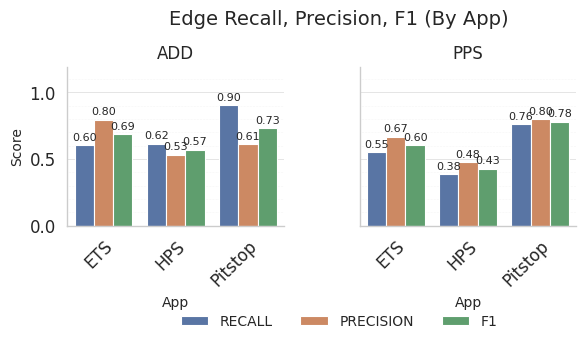

**Edge Recall, Precision, F1 — By App (Aggregated)**

RECALL        PRECISION            F1       
method_label    ADD    PPS       ADD    PPS    ADD    PPS
App                                                      
ETS           0.603  0.552     0.795  0.667  0.686  0.604
HPS           0.615  0.385     0.533  0.476  0.571  0.426
Pitstop       0.905  0.762     0.613  0.800  0.731  0.780

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{RECALL} & \multicolumn{2}{r}{PRECISION} & \multicolumn{2}{r}{F1} \\
method_label & ADD & PPS & ADD & PPS & ADD & PPS \\
App &  &  &  &  &  &  \\
\midrule
ETS & 0.603 & 0.552 & 0.795 & 0.667 & 0.686 & 0.604 \\
HPS & 0.615 & 0.385 & 0.533 & 0.476 & 0.571 & 0.426 \\
Pitstop & 0.905 & 0.762 & 0.613 & 0.800 & 0.731 & 0.780 \\
\bottomrule
\end{tabular}



**Edge Recall, Precision, F1 — Unaggregated**

,Method,App,RECALL,PRECISION,F1
0,ADD,ETS,0.603,0.795,0.686
1,ADD,HPS,0.615,0.533,0.571
2,ADD,Pitstop,0.905,0.613,0.731
3,PPS,ETS,0.552,0.667,0.604
4,PPS,HPS,0.385,0.476,0.426
5,PPS,Pitstop,0.762,0.800,0.780


\begin{tabular}{lllrrr}
\toprule
 & Method & App & RECALL & PRECISION & F1 \\
\midrule
0 & ADD & ETS & 0.603 & 0.795 & 0.686 \\
1 & ADD & HPS & 0.615 & 0.533 & 0.571 \\
2 & ADD & Pitstop & 0.905 & 0.613 & 0.731 \\
3 & PPS & ETS & 0.552 & 0.667 & 0.604 \\
4 & PPS & HPS & 0.385 & 0.476 & 0.426 \\
5 & PPS & Pitstop & 0.762 & 0.800 & 0.780 \\
\bottomrule
\end{tabular}



In [3]:
setup_style()
for section in METRIC_SECTIONS:
    render_section(df, section, SHORT_LABELS)